# <center>Motivation</center>

<p align="justify">In this file, we are going to test some machine learning classification algorithms that can predict diabetes cases.</p>

## <div id = "1">1) Importing libraries</div>

<p align="justify">In order to create a machine learning model that can estimates whether a patient has or has not tendencies with diabetes, we need to import libraries that can handle machine learning and data analysis workflows.</p>

<ul>
    <li>Third party packages:
        <ul>
            <li>
                <b><a href = "https://matplotlib.org/stable/index.html" target="blank">matplotlib</a></b>: to customize and create our own graphs in order to understand the data;
            </li>
            <li>
                <b><a href = "https://numpy.org/doc/stable/" target="blank">numpy</a></b>: to work and handle data more efficiently;
            </li>
            <li>
                <b><a href = "https://docs.pola.rs/api/python/stable/reference/index.html" target="blank">polars</a></b>: for fast data manipulation;
            </li>
            <li>
                <b><a href = "https://scikit-learn.org/stable/">scikit-learn</a></b>: for data algoritms;
            </li>
            <li>
                <b><a href = "https://www.tensorflow.org/learn?hl=pt-br">tensorflow</a></b>: to create neural networks;
            </li>
        </ul>
    </li>
    <li>Functions:
        <ul>
            <li>
                <b><a href = "./functions/plots.py" target="blank">plots</a></b>: to help create plots already determined;
            </li>
            <li>
                <b><a href = "./functions/statistics.py" target="blank">statistics</a></b>: to help calculate values more easy;
            </li>
        </ul>
    </li>
</ul>

In [1]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, make_scorer, f1_score, accuracy_score, recall_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifier, SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from imblearn.under_sampling import TomekLinks

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import polars as pl

from pathlib import Path

import joblib

from functions import plots, statistics

## 2) Reading dataset

### 2.1) Importing <code>.parquet</code> dataset

In [2]:
dataset = pl.read_parquet(
    source = "./dataset/cleaned_dataset.parquet"
)

print(
    f'Estimated size:, {dataset.estimated_size(unit = "mb"):.3f}Mb'
)
print(dataset.shape)
dataset.head(2)

Estimated size:, 2.494Mb
(249049, 20)


HIGHT_BLOOD_PRESURE,HAS_HIGHT_CHOLESTEROL,HAS_CHECKED_CHOLESTEROL,IS_SMOKER,HAD_STROKE,HAD_HEARTH_ATTACK_OR_DISEASE,HAVE_EXERCISED,HAD_FRUITS,HAD_VEGGIES,CONSUME_ALCOOL,HAS_HEALTHCARE,NO_DOCTOR_APPOINTMENT_BY_COST,BODY_MASS,DAYS_BAD_MENTAL_HEALTH,AGE_RANGE,EDUCATION_LEVEL,DIABETES_LEVEL,PCA_HEALTH_&_INJURY_&_WALK_DIFFICULTY,SEX_female,SEX_male
bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,i8,i8,i8,i8,enum,f16,i8,i8
true,true,true,true,false,false,false,false,true,false,true,false,4,2,8,3,"""no_diabetes""",2.396484,1,0
false,false,false,true,false,false,true,false,false,false,false,true,1,0,6,5,"""no_diabetes""",0.357422,1,0


### 2.2) Plotting <code>DIABETES_LEVEL</code> imbalance

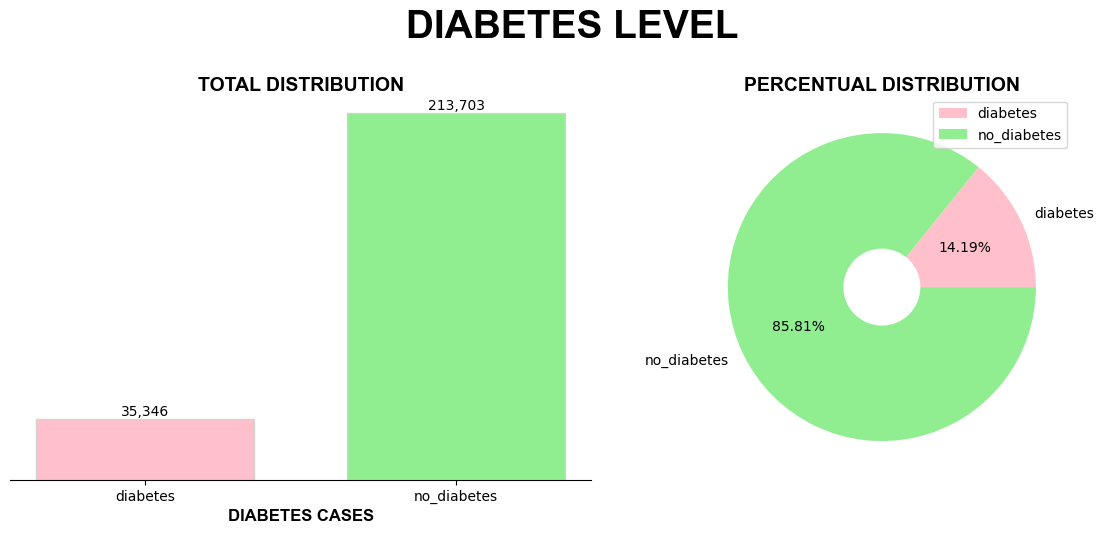

In [3]:
fig, axs = plt.subplots(
    figsize = (15, 5),
    ncols = 2,
    gridspec_kw = {
        "wspace": .0
    }
)

# Getting total and relative frequency for each category in DIABETES_LEVEL:
plot_df = dataset.group_by(
    ["DIABETES_LEVEL"]
).agg(
    pl.col("DIABETES_LEVEL").len().cast(pl.Int32).alias("TOTAL")
).with_columns(
    (pl.col("TOTAL")/pl.col("TOTAL").sum()).alias("PERCENTAGE")
).sort(
    "TOTAL"
)

# Setting a bar plot for total cases in DIABETES_LEVEL
plots.plot_bar(
    ax = axs[0],
    x_values = plot_df["DIABETES_LEVEL"],
    y_values = plot_df["TOTAL"],
    colors = ["pink", "lightgreen",],
    legends = plot_df["DIABETES_LEVEL"],
    formater = "{:,.0f}",
    title = {
        "text": f"TOTAL DISTRIBUTION",
        "font": "arial",
        "size": 14,
    },
    x_label = {
        "text": "DIABETES CASES",
        "font": "arial",
        "size": 12,
    },
    y_label = {
        "text": "",
        "font": "arial",
        "size": 12
    },
    width = .7,
    tooltip_align = "edge"
)

# Setting a pie plot for percentual cases in DIABETES_LEVEL:
plots.plot_pie(
    ax = axs[1],
    values = plot_df["PERCENTAGE"],
    labels = plot_df["DIABETES_LEVEL"],
    colors = ["pink", "lightgreen",],
    title = {
        "text": f"PERCENTUAL DISTRIBUTION",
        "font": "arial",
        "size": 14,
    },
)

plt.legend()
plt.suptitle("DIABETES LEVEL", fontsize = 28, y = 1.05, fontname = "arial", fontweight = "bold")
plt.show()

### 2.3) Separating dataset into train and test samples

<p align="justify">Here, we need to further preprare for data leake problems related to the training process. For that, we must split the dataset into training and test before handling any imbalancing. Also, the paramn <code>stratify</code> is used to create a split method based on the distribution of target column.</p>

In [ ]:
dataset = dataset.to_pandas()
dataset["DIABETES_LEVEL"] = dataset["DIABETES_LEVEL"].astype(str).str.strip()

dataset = dataset[dataset["DIABETES_LEVEL"].isin(["diabetes", "no_diabetes"])]

target_map = {"no_diabetes": 0, "diabetes": 1}
dataset["DIABETES_LEVEL"] = dataset["DIABETES_LEVEL"].map(target_map).astype('int32')

X_train, x_test, y_train, y_test = train_test_split(
    dataset.drop("DIABETES_LEVEL", axis = 1), dataset["DIABETES_LEVEL"],
    test_size = 0.20,
    stratify = dataset["DIABETES_LEVEL"]
)

print(
    y_train.value_counts(normalize = True), y_test.value_counts(normalize = True), sep = " ", end = " "
)

DIABETES_LEVEL
0    0.858075
1    0.141925
Name: proportion, dtype: float64 DIABETES_LEVEL
0    0.858081
1    0.141919
Name: proportion, dtype: float64 

### 2.4) Handling imbalance

<p align="justify">Here, we finally handle the problem of imbalancing. We should only train our future models on balanced dataset.</p>

In [5]:
tomek_sampler = TomekLinks()

X_resampled , y_resampled = tomek_sampler.fit_resample(
    X = X_train,
    y = y_train
)

## 3) Testing models

### 3.1) Creating testing models

<p align="justify">Here, we are going to train these models:</p>

<ul>
    <li>RidgeClassifier;</li>
    <li>SGDClassifier;</li>
    <li>LogisticRegression;</li>
    <li>KNeighborsClassifier;</li>
    <li>RandomForestClassifier;</li>
    <li>ExtraTreesClassifier;</li>
    <li>DecisionTreeClassifier;</li>
    <li>XGBClassifier;</li>
    <li>GradientBoostingClassifier;</li>
    <li>MLPClassifier;</li>
</ul>

In [96]:
custom_score = make_scorer(
    roc_auc_score,
    response_method=('predict_proba', 'decision_function')
)

models = [
    {
        "model": RidgeClassifier(class_weight = 'balanced'),
        "X_train": X_train,
        "y_train": y_train,
        "scoring": custom_score,
        "param_grid": {
            "alpha": [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1, 1.5, 2],
            "solver": ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
        },
        "path": "./models/ridge.joblib"
    },
    {
        "model": SGDClassifier(class_weight = 'balanced'),
        "X_train": X_train,
        "y_train": y_train,
        "scoring": custom_score,
        "param_grid": {
            "loss": ['hinge', 'log_loss', 'perceptron', 'squared_error', 'huber'],
            "penalty": ['l2', 'l1', 'elasticnet'],
            "alpha": [0.0001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10],
            "l1_ratio": [0.0001, 0.001, 0.01, 0.02, 0.05, 1]
        },
        "path": "./models/SGD.joblib"
    },
    {
        "model": LogisticRegression(class_weight = 'balanced'),
        "X_train": X_train,
        "y_train": y_train,
        "scoring": custom_score,
        "param_grid": {
            "penalty": ['l2'],
            "solver": ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
            "C": [0.0001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10],
        },
        "path": "./models/logistic.joblib"
    },
    {
        "model": KNeighborsClassifier(),
        "X_train": X_resampled,
        "y_train": y_resampled,
        "scoring": custom_score,
        "param_grid": {
            "n_neighbors": [5, 7, 10, 15, 20, 30],
            "weights": ['uniform', 'distance'],
            "algorithm": ['auto'],
            "leaf_size": [20, 30, 40],
            "p": [1, 2]
        },
        "path": "./models/kneighbors.joblib"
    },
    {
        "model": RandomForestClassifier(n_jobs = -1, class_weight = 'balanced'),
        "X_train": X_train,
        "y_train": y_train,
        "scoring": custom_score,
        "param_grid": {
            "n_estimators": [50, 100, 150, 200, 250, 300, 350, 400],
            "criterion": ['gini', 'entropy', 'log_loss'],
            "max_features": ['sqrt', 'log2'],
        },
        "path": "./models/randomforest.joblib"
    },
]



### 3.2) Training models

In [ ]:
for model in models[-5:]:
    statistics.getting_best_model(
        **model
    )

## 4) Evaluating models

### 4.1) Scores

<p align="justify">Here, we are going to evaluate each trained model based on these metrics:</p>

<ul>
    <li>F1</li>
    <li>accurary</li>
    <li>recall</li>
</ul>

In [6]:
result_schema = {
    "NAME": pl.String,
    "F1": pl.Float16,
    "ACCURACY": pl.Float16,
    "RECALL": pl.Float16
}

result_df = pl.DataFrame(
    schema = result_schema
)

matrices = []

y_test_num = y_test.to_numpy()

for archive in [archive for archive in Path("./models/").iterdir() if archive.name != "pre_processing.joblib"]:

    model = joblib.load(filename=archive)
    y_raw_pred = model.predict(x_test)

    if isinstance(y_raw_pred[0], str):
        y_pred = np.array([1 if p == "diabetes" else 0 for p in y_raw_pred])
    else:
        y_pred = y_raw_pred

    matrices.append({
        "name": archive.name.split(".")[0],
        "matrix": confusion_matrix(y_true=y_test_num, y_pred=y_pred)
    })

    result_df = pl.concat(
        items = [
            result_df,
            pl.DataFrame(
                data = {
                    "NAME": archive.name.split(".")[0],
                    "F1": f1_score(y_true=y_test_num, y_pred=y_pred),
                    "ACCURACY": accuracy_score(y_true=y_test_num, y_pred=y_pred),
                    "RECALL": recall_score(y_true=y_test_num, y_pred=y_pred)
                },
                schema = result_schema
            )
        ]
    )

result_df = result_df.sort(
    by = "F1",
    descending = True
)

print(result_df.shape)
display(result_df)

(5, 4)


NAME,F1,ACCURACY,RECALL
str,f16,f16,f16
"""randomforest""",0.770996,0.931641,0.809082
"""logistic""",0.452637,0.734863,0.772461
"""ridge""",0.447754,0.7265625,0.780273
"""SGD""",0.398682,0.614746,0.900391
"""kneighbors""",0.31958,0.866211,0.221069


### 4.2) Plotting confusion_matrix

<p align="justigy">Here, the overall winner model seems to be <code>randomforest.joblib</code></p>

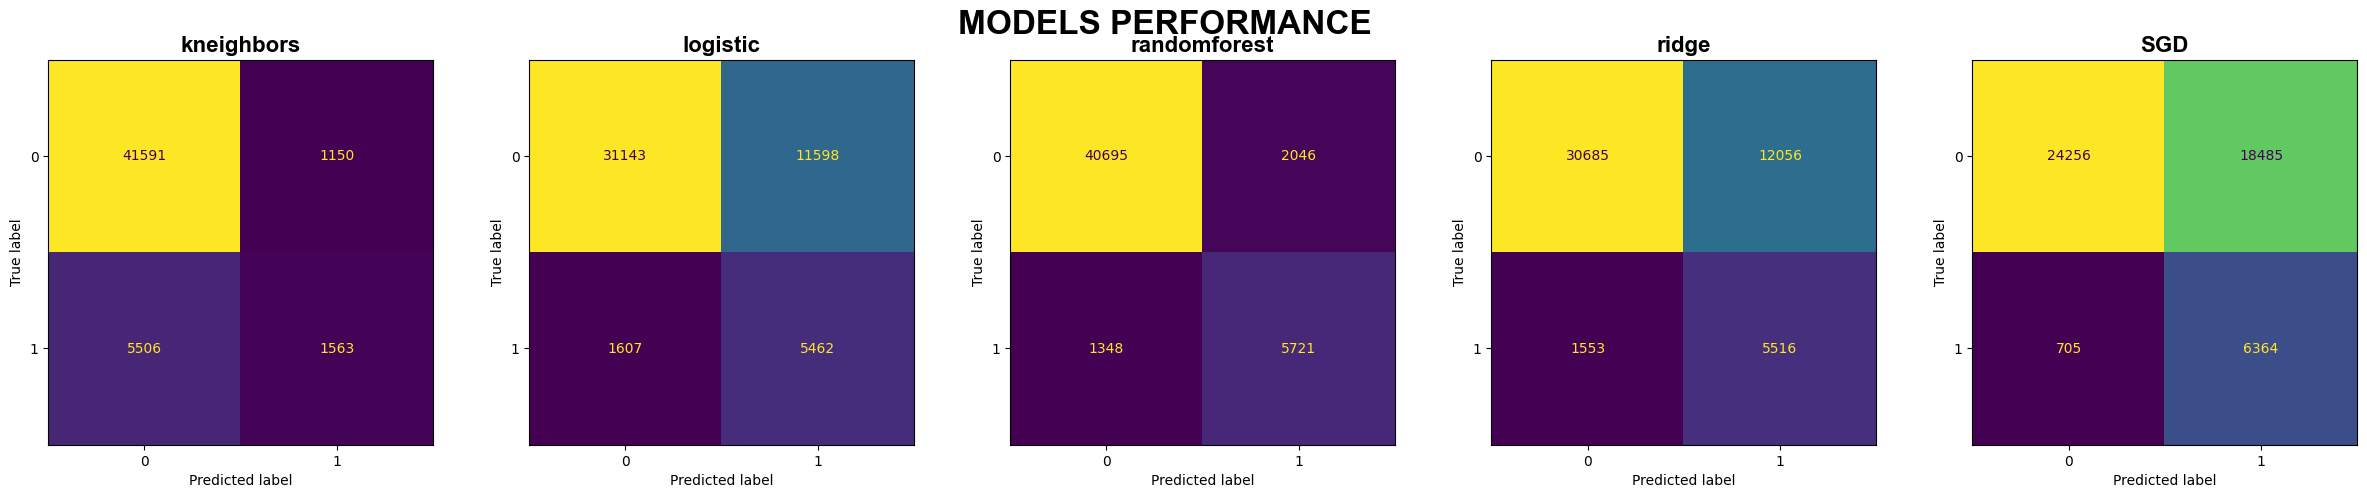

In [7]:
fig, ax = plt.subplots(
    ncols = 5,
    figsize = (30, 5),
    gridspec_kw = {
        "hspace": 0.3
    }
)

ax = ax.flatten()

for index, matrix in enumerate(matrices):

    cm_plot = ConfusionMatrixDisplay(
        confusion_matrix = matrix["matrix"],
    )

    cm_plot.plot(
        ax = ax[index],
        colorbar = False
    )
    ax[index].set_title(
        matrix["name"],
        fontsize = 16,
        fontweight = "bold",
        fontfamily = "arial"
    )

plt.suptitle(
    t = "MODELS PERFORMANCE",
    fontsize = 24,
    fontweight = "bold",
    fontfamily = "arial"
)
plt.show()

## 5) Improving <code>randomforest</code>

In [18]:
model = joblib.load(
    filename = "./models/randomforest.joblib"
)

model

,n_estimators,350
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 5.1) Getting feature importances

<p align="justify">There is a change that some features may have not high importance at all. So maybe we could improve our model performance if we try to drop features based on your feature_importance range.</p>

In [19]:
feature_df = pl.DataFrame(
    data = {
        "NAMES": model.feature_names_in_,
        "FEATURE_IMPORTANCE": model.feature_importances_
    }
).sort(
    by = "FEATURE_IMPORTANCE",
    descending = True
)

with pl.Config(tbl_rows = 20):
    display(feature_df)

NAMES,FEATURE_IMPORTANCE
str,f64
"""PCA_HEALTH_&_INJURY_&_WALK_DIF…",0.286442
"""AGE_RANGE""",0.177725
"""BODY_MASS""",0.09
"""EDUCATION_LEVEL""",0.083514
"""HIGHT_BLOOD_PRESURE""",0.071704
"""HAS_HIGHT_CHOLESTEROL""",0.037166
"""HAD_FRUITS""",0.036428
"""IS_SMOKER""",0.035069
"""HAD_VEGGIES""",0.027749


### 5.2) Retraining 

#### 5.2.1) Droping features with less than 0.02 feature importance

In [20]:
first_model_removed_02 = RandomForestClassifier(
    **model.get_params()
)

drop_columns_02 = feature_df.filter(
    pl.col("FEATURE_IMPORTANCE") < .02
)["NAMES"]

first_model_removed_02.fit(
    X = X_train.drop(drop_columns_02, axis = 1),
    y = y_train
)

,n_estimators,350
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 5.2.2) Droping features with less than 0.01 feature importance

In [21]:
first_model_removed_01 = RandomForestClassifier(
    **model.get_params()
)

drop_columns_01 = feature_df.filter(
    pl.col("FEATURE_IMPORTANCE") < .01
)["NAMES"]

first_model_removed_01.fit(
    X = X_train.drop(drop_columns_01, axis = 1),
    y = y_train
)

,n_estimators,350
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 5.3) Getting models thresholds ranges

<p align="justify">Now that we have all models trained based on certain important features, we now can make a series of plots that could show us the limit bettwen each diabetes and no_diabetes probability range.</p>

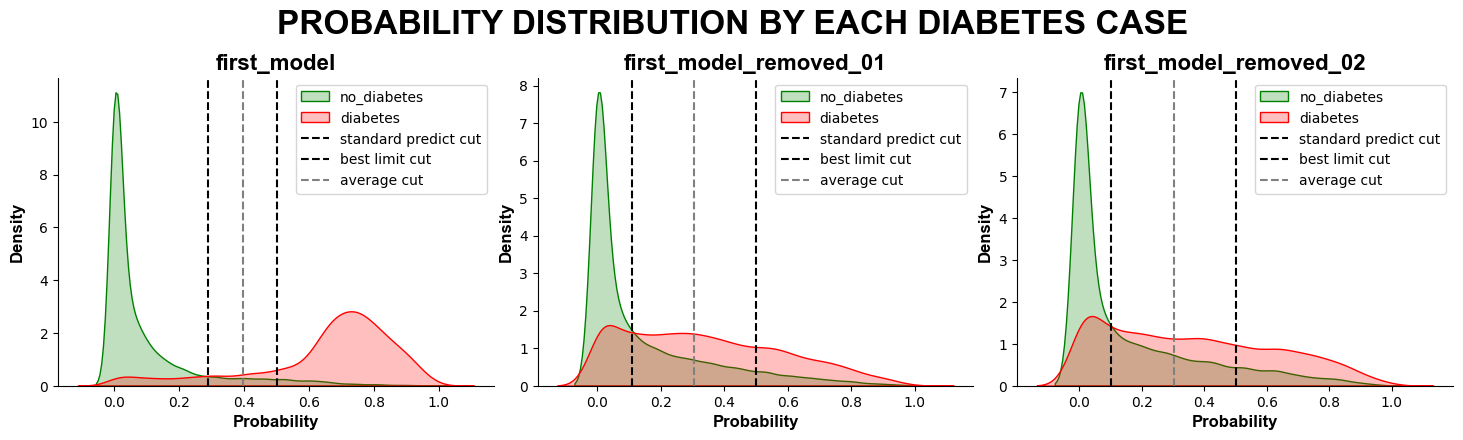

In [ ]:
y_probs = [
     {
          "name": "first_model",
          "prob": model.predict_proba(x_test)[:, 1]
     },
     {
          "name": "first_model_removed_01",
          "prob": first_model_removed_01.predict_proba(x_test.drop(
               drop_columns_01, axis = 1
          ))[:, 1],
     },
     {
          "name": "first_model_removed_02",
          "prob": first_model_removed_02.predict_proba(x_test.drop(
              drop_columns_02, axis = 1
          ))[:, 1],
     },
]

fig, axs = plt.subplots(
     ncols = 3,
     figsize = (18, 4),
     gridspec_kw = {
          "wspace": 0.1
     }
)

axs = axs.flatten()

for index, y_prob in enumerate(y_probs):

     fpr, tpr, thresholds = roc_curve(y_test, y_prob["prob"])
     j_scores = tpr - fpr
     best_idx = np.argmax(j_scores)
     best_threshold = thresholds[best_idx]

     sns.kdeplot(y_prob["prob"][y_test == 0], ax = axs[index], fill = True, label = "no_diabetes", color = "green", common_norm = False)
     sns.kdeplot(y_prob["prob"][y_test == 1], ax = axs[index], fill = True, label = "diabetes", color = "red", common_norm = False)

     axs[index].axvline(x = 0.5, color = 'black', linestyle='--', label = 'standard predict cut')
     axs[index].axvline(x = best_threshold, color = 'black', linestyle='--', label = 'best limit cut')
     axs[index].axvline(x = (0.5 + best_threshold)/2, color = 'gray', linestyle='--', label = 'average cut')

     axs[index].set_title(f"{y_prob['name']}", fontsize = 16, fontweight = "bold", fontfamily = "arial")
     axs[index].set_xlabel("Probability", fontsize = 12, fontweight = "bold", fontfamily = "arial")
     axs[index].set_ylabel("Density", fontsize = 12, fontweight = "bold", fontfamily = "arial")

     axs[index].spines[["top", "right"]].set_visible(False)
     axs[index].legend()

plt.suptitle(
     t = "PROBABILITY DISTRIBUTION BY EACH DIABETES CASE",
     y = 1.05,
     fontsize = 24,
     fontweight = "bold",
     fontfamily = "arial"
)
plt.show()

<p align="justify">As we can see, even though there are column with feature importance lower than 0.02 or even 0.01, we could understand that removing those columns are a mistake because - after comparing <code>first_model_removed_01</code> and <code>first_model_removed_02</code> with <code>first_model</code>, we can cleary see the difference bettween them: <code>first_model</code> can separate diabetes cases more easily.</p>

### 5.4) Ploting confusion matrix for each thresholds

<p align="justify">If we are only interested to know if a certain patient has or has not diabetes, we need to give a straight answer based on probability. However, we are going to check if changing those probabilities could improve our model or increase our chances to find diabetes cases without creating so much false negative cases.</p>

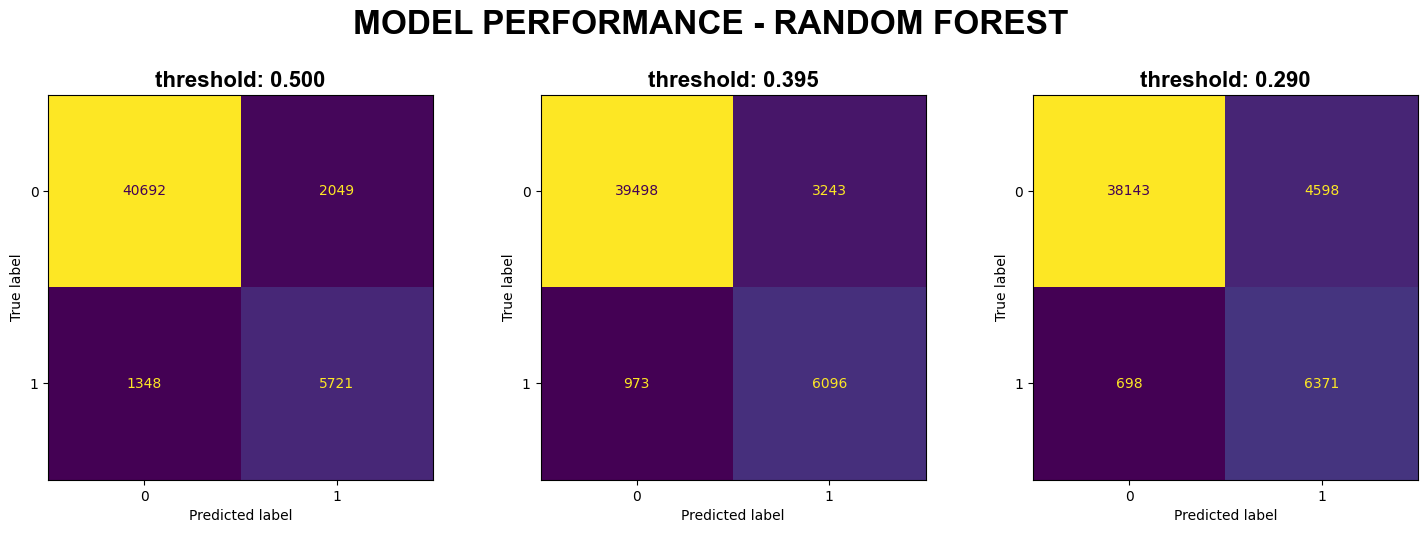

In [33]:
fig, ax = plt.subplots(
    ncols = 3,
    figsize = (18, 5),
)

y_pred_probs = model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

thresholds = [0.5, (best_threshold + 0.5)/2, best_threshold]

for index, threshold in enumerate(thresholds):

    y_pred_custom = (y_pred_probs >= threshold).astype(int)

    cm_plot = ConfusionMatrixDisplay(
        confusion_matrix = confusion_matrix(
            y_true = y_test,
            y_pred = y_pred_custom
        ),
    )

    cm_plot.plot(
        ax = ax[index],
        colorbar = False
    )
    ax[index].set_title(
        f"threshold: {threshold:.3f}",
        fontsize = 16,
        fontweight = "bold",
        fontfamily = "arial"
    )

plt.suptitle(
    t = "MODEL PERFORMANCE - RANDOM FOREST",
    y = 1.05,
    fontsize = 24,
    fontweight = "bold",
    fontfamily = "arial"
)
plt.show()

<p align="justify">As we saw on top, only with <code>threshold = 0.29</code> we were able to detect the most diabetes cases without compromising to much of false negatives cases. <br/><br/>However, for pratice purposes, we cannot only say <q><i>yes</i></q> we or <q><i>no</i></q> for clinical conditions, therefore, we are going to return a probability matrix related to each target class. And, for pragmatism, we are going to consider the following table to specify the range for each degree of diabetes:</p>

<center>
    <table>
        <thead>
            <tr>
                <th><center>RANGE</center></th>
                <th><center>DIABETES PROBABILITY</center></th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>0.00 - 0.29</td>
                <td>low risk</td>
            </tr>
            <tr>
                <td>0.29 - 0.50</td>
                <td>average risk</td>
            </tr>
            <tr>
                <td>0.50 - 1.00</td>
                <td>high risk</td>
            </tr>
        </tbody>
    </table>
</center>

## 6) Creating Pipeline

### 6.1) Process

In [34]:
pre_processing = joblib.load(
    filename = "./models/pre_processing.joblib"
)

pipeline = Pipeline(
    steps = [
        ("pre_processing", pre_processing),
        ("model", model)
    ]
)

pipeline

,steps,"[('pre_processing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pca_transformer', ...), ('days_bad_mental_health_standard_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 6.2) Saving pipeline

In [35]:
joblib.dump(
    value = pipeline,
    filename = "./models/diabetes_model.joblib"
)

['./models/diabetes_model.joblib']